In [1]:
"""Smoke-test for the NEW Rossmann forecasting pipeline (hypertuning).

Runs the full feature-engineering -> target-transform -> inner-CV objective and
refit flow on a few real stores, then exercises hypertuning.optimize end-to-end
to validate the updated TimeSeriesCV(n_splits, train_size, test_size) API.
"""

import os
import logging
import warnings

import optuna
import pandas as pd
import matplotlib.pyplot as plt
import src.constants as C

from sklearn.metrics import mean_absolute_error

from src import features
from src.preprocessing import preprocess_data
from src.engine import hypertuning, utils
from src.engine.cv import TimeSeriesCV
from src.engine.target_transformer import TargetTransformer


os.makedirs(C.LOG_DIR, exist_ok=True)
logging.basicConfig(level=logging.INFO,
                    filename=os.path.join(C.LOG_DIR, "test_pipeline_new.log"),
                    format="%(levelname)s  %(message)s")
optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings("ignore")

logger = logging.getLogger(__name__)


def plot_actual_vs_predicted(results, n_days_to_plot, n_days_offset):
        
    max_date = results.index.get_level_values("Date").max() - pd.Timedelta(days=n_days_offset)
    min_date = max_date - pd.Timedelta(days=n_days_to_plot)

    actuals_recent = results.loc[(slice(None), slice(min_date, max_date)), 'Sales_actual']
    preds_recent   = results.loc[(slice(None), slice(min_date, max_date)), 'Sales_predicted']

    plot_stores = actuals_recent.index.get_level_values("Store").unique()

    fig, ax = plt.subplots(figsize=(12, 2 * len(plot_stores)), nrows=len(plot_stores), sharex=True, sharey=False)

    for i, store in enumerate(plot_stores):

        actual_store_sales    = actuals_recent.loc[(store, slice(None))].copy()
        predicted_store_sales = preds_recent.loc[(store, slice(None))].copy()

        actual_store_sales.fillna(method='ffill', inplace=True)     # Forward fill to maintain continuity in the plot
        predicted_store_sales.fillna(method='ffill', inplace=True)  # Forward fill to maintain continuity in the plot

        actual_store_sales.plot(label="Actual", ax=ax[i])
        predicted_store_sales.plot(label="Predicted", ax=ax[i], linestyle='--')

        ax[i].set_ylabel("Store {}".format(store))
        ax[i].set_xlabel("Date")

    plt.suptitle("Actual vs Predicted Sales for Each Store (Last {} Days)".format(n_days_to_plot), fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # Adjust layout to make room for the suptitle
    

c:\Users\m_kal\Downloads\rossmann_store_sales\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Config

`config` merges the CV and study settings so `hypertuning.optimize` can read the inner-CV keys (`n_inner_splits`, `inner_train_size`, `inner_test_size`) used by the new `TimeSeriesCV` API.

In [2]:
config = {
    "storage_url":           C.STORAGE_URL,
    "forecast_horizon":      C.FORECAST_HORIZON,
    "n_trials":              C.NUM_TRIALS,
    "n_startup_trials":      C.NUM_STARTUP_TRIALS,
    "n_jobs":                C.NUM_JOBS,
    "seed":                  C.SEED,
    "xgb_constants":         C.XGB_CONSTANTS,
    "early_stopping_rounds": C.EARLY_STOPPING_ROUNDS,
    "num_boost_rounds":      C.NUM_BOOST_ROUNDS,
    "monitor_periods":       C.MONITOR_PERIODS,
    "hyperparameters":       C.HYPERPARAMETERS,
    "log_dir":               C.LOG_DIR,
    "n_outer_splits":        C.N_OUTER_SPLITS,
    "n_inner_splits":        C.N_INNER_SPLITS,
}

fe_config = {
    "lags":                  C.LAGS,
    "diffs":                 C.DIFFS,
    "roll_windows":          C.ROLL_WINDOWS,
}

In [3]:
""" Read the Rossmann store sales dataset and preprocess it for modeling. """

sales = pd.read_csv(r"C:/Users/m_kal/Downloads/datasets/rossmann-store-sales/train.csv")
stores = pd.read_csv(r"C:/Users/m_kal/Downloads/datasets/rossmann-store-sales/store.csv")

stores_to_use = [1, 2, 3]
stores = stores[stores['Store'].isin(stores_to_use)]

df = preprocess_data(sales, stores)

# Feature engineering + target transform (new pipeline)

In [4]:
horizon = pd.DateOffset(days=config['forecast_horizon'])

y = df.set_index(['Store', 'Date'])['Sales']

X = (df
     .set_index(['Date'])
     .groupby('Store')
     .apply(lambda df: features.compute(df, fe_config["lags"], fe_config["diffs"], fe_config["roll_windows"], horizon)))

trf = TargetTransformer(forecast_horizon=pd.DateOffset(days=-config['forecast_horizon']),
                        anchor_col='lag_days_0')
trf.fit(X)

y = trf.transform(y)    # forward difference target
X = X.loc[y.index]      # align features with target

# Single-trial smoke test of `_objective`

In [6]:
from optuna.trial import FixedTrial
from src.engine.hypertuning import _objective


num_days = X.index.get_level_values("Date").nunique()
cv_sizes = utils.compute_cv_sizes(num_days,
                                  config['forecast_horizon'],
                                  config['n_outer_splits'],
                                  config['n_inner_splits'])

config.update(cv_sizes)

inner_cv = TimeSeriesCV(n_splits=config['n_inner_splits'],
                        train_size=config['inner_train_size'],
                        test_size=config['inner_test_size'],
                        gap=config['forecast_horizon'])

# Values must fall within the bounds defined in C.HYPERPARAMETERS
params = {
    'max_depth': 6,
    'learning_rate': 1e-3,
    'subsample': 0.7,
    'colsample_bytree': 1.0,
    'min_child_weight': 1,
    'reg_alpha': 0.1,
    'reg_lambda': 0.1,
    'gamma': 0.1,
}

mock_trial = FixedTrial(params)
obj_fcn = lambda trial: _objective(trial, X, y, inner_cv,
                                   study_name='stuff_new',
                                   study_config=config)

obj_fcn(mock_trial)

[0]	train-rmse:4.79693+0.00974	test-rmse:4.42232+0.43860
[100]	train-rmse:4.34335+0.00878	test-rmse:4.00136+0.39774
[200]	train-rmse:3.93302+0.00804	test-rmse:3.62101+0.35979
[300]	train-rmse:3.56187+0.00739	test-rmse:3.27694+0.32516
[400]	train-rmse:3.22624+0.00674	test-rmse:2.96568+0.29398
[500]	train-rmse:2.92260+0.00612	test-rmse:2.68421+0.26554
[600]	train-rmse:2.64798+0.00558	test-rmse:2.42965+0.23950
[700]	train-rmse:2.39968+0.00509	test-rmse:2.19931+0.21573
[800]	train-rmse:2.17516+0.00470	test-rmse:1.99097+0.19420
[900]	train-rmse:1.97226+0.00432	test-rmse:1.80268+0.17457
[1000]	train-rmse:1.78888+0.00401	test-rmse:1.63236+0.15672
[1100]	train-rmse:1.62328+0.00373	test-rmse:1.47820+0.14062
[1200]	train-rmse:1.47374+0.00350	test-rmse:1.33887+0.12571
[1300]	train-rmse:1.33871+0.00330	test-rmse:1.21273+0.11212
[1400]	train-rmse:1.21689+0.00311	test-rmse:1.09870+0.09970
[1500]	train-rmse:1.10699+0.00290	test-rmse:0.99541+0.08836
[1600]	train-rmse:1.00794+0.00270	test-rmse:0.90219+

np.float64(0.09833011590845385)

MAE: 432.23


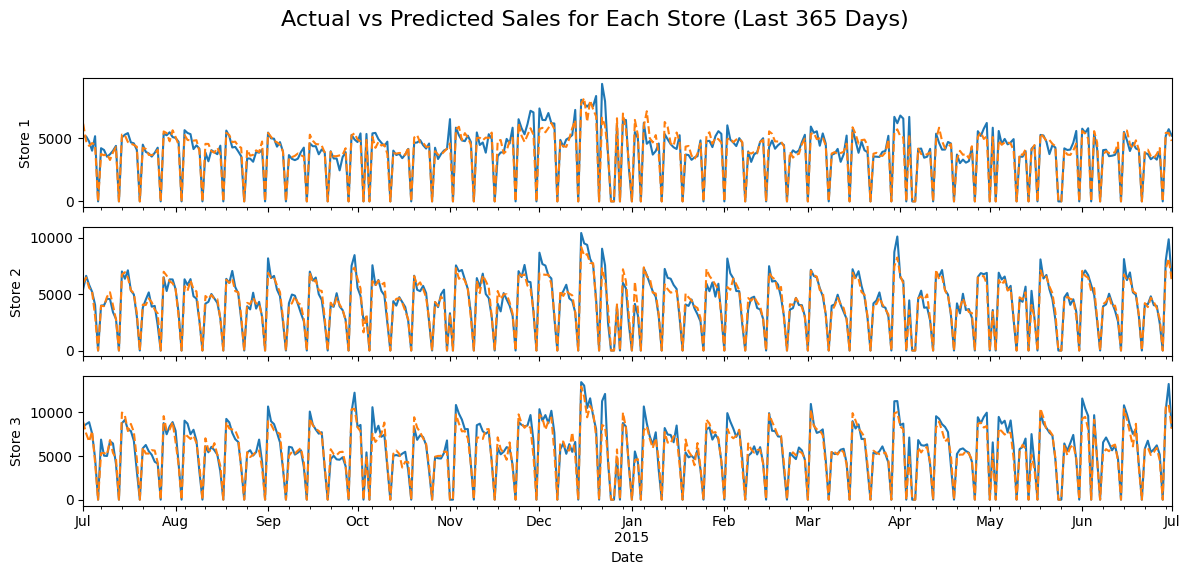

In [7]:
booster = utils.refit(X, y, mock_trial, config)
actuals = df.set_index(['Store', 'Date'])['Sales']
preds   = utils.predict(X, booster, trf)
results = pd.merge(actuals, preds, left_index=True, right_index=True, suffixes=('_actual', '_predicted'))
mae     = mean_absolute_error(results["Sales_actual"], results["Sales_predicted"])

print(f"MAE: {mae:.2f}")
plot_actual_vs_predicted(results, 365, 30)

# End-to-end `optimize`

Runs a couple of Optuna trials through the new `optimize`. Set `n_trials` small for a quick check.

[0]	train-rmse:4.57347+0.00997	test-rmse:4.51306+0.01431
[0]	train-rmse:4.56613+0.00941	test-rmse:4.50575+0.01364
[100]	train-rmse:0.20948+0.00122	test-rmse:0.11547+0.02685
[123]	train-rmse:0.17736+0.00289	test-rmse:0.11308+0.02495
Best trial: #1
Best value (rmse): 0.112457
Best params: {'max_depth': 5, 'learning_rate': 0.04876572034615957, 'subsample': 0.9787088665181481, 'colsample_bytree': 0.7963686356945008, 'min_child_weight': 5, 'reg_alpha': 0.002463380225158463, 'reg_lambda': 0.019866929302789455, 'gamma': 0.13271014550851334}
Refit MAE: 482.04


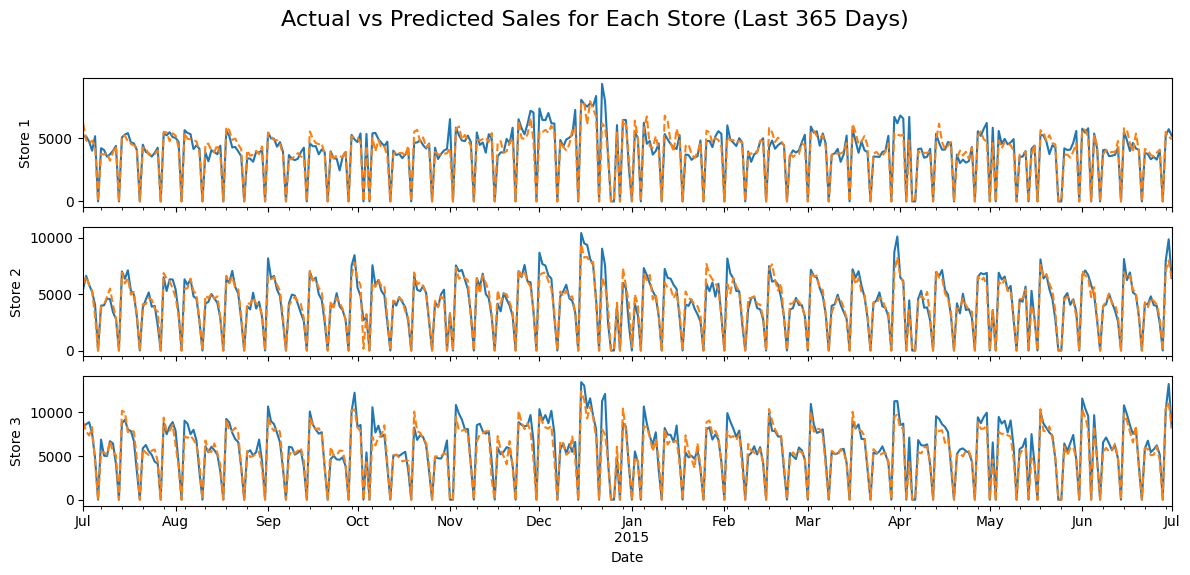

In [8]:
opt_config = config.copy()
opt_config.update({
    "n_outer_splits": 2,
    "n_inner_splits": 2,
    "n_trials": 2,
    "n_startup_trials": 1,
})

# get current timestamp
now = pd.Timestamp.now().strftime("%Y%m%d_%H%M%S")
hypertuning.optimize(study_name=f'smoke_study_{now}', X_train=X, y_train=y, config=opt_config)
study = optuna.load_study(study_name=f'smoke_study_{now}', storage=opt_config["storage_url"])

# Refit a model on the full dataset using the best hyperparameters
best_bst   = utils.refit(X, y, study.best_trial, opt_config)
best_preds = utils.predict(X, best_bst, trf)
actuals    = df.set_index(['Store', 'Date'])['Sales']
best_res   = pd.merge(actuals, best_preds, left_index=True, right_index=True, suffixes=('_actual', '_predicted'))
best_mae   = mean_absolute_error(best_res["Sales_actual"], best_res["Sales_predicted"])

print(f"Best trial: #{study.best_trial.number}")
print(f"Best value ({opt_config['xgb_constants']['eval_metric']}): {study.best_trial.value:.6f}")
print(f"Best params: {study.best_trial.params}")
print(f"Refit MAE: {best_mae:.2f}")
plot_actual_vs_predicted(best_res, 365, 30)

# Nested cross-validation (out-of-fold predictions)

Run 3 outer folds, each test window equal to `FORECAST_HORIZON` steps per store. On every outer fold we tune hyperparameters on the training portion, refit with the best params, and predict the held-out test window. The out-of-fold predictions are then collected and plotted per store.

In [ ]:
from sklearn.metrics import mean_absolute_error

num_days = X.index.get_level_values("Date").nunique()
cv_sizes = utils.compute_cv_sizes(num_days, config['forecast_horizon'], config['n_outer_splits'], config['n_inner_splits'])
config.update(cv_sizes)  # Update config with calculated CV sizes

outer_cv = TimeSeriesCV(n_splits=config['n_outer_splits'],
                        train_size=config['outer_train_size'],
                        test_size=config['outer_test_size'],
                        gap=config['forecast_horizon'])

oof_preds = []
for fold, (train_idx, test_idx) in enumerate(outer_cv.split(X), start=1):

    print(f"\n=== Outer fold {fold}/{config['n_outer_splits']}")

    # Split the data into training and test sets for the current outer fold
    X_train = X.iloc[train_idx]
    y_train = y.iloc[train_idx]
    X_test  = X.iloc[test_idx]

    # 1) Hyperparameter tuning on the outer-fold training data (embargoed inner CV inside optimize).
    study_name = f"nested_outer_{fold}"
    hypertuning.optimize(study_name=study_name, X_train=X_train, y_train=y_train, config=config)

    # 2) Refit on the outer-fold training data using the best hyperparameters.
    study = optuna.load_study(study_name=study_name, storage=config["storage_url"])
    model = utils.refit(X_train, y_train, study.best_trial, config)

    # 3) Predict the held-out test window and store the out-of-fold predictions.
    fold_preds = utils.predict(X_test, model, trf)  # Use the utility function to get predictions
    oof_preds.append(fold_preds)

# Combine all out-of-fold predictions and invert the target transform.
oof_results = pd.merge(left=df.set_index(['Store', 'Date'])['Sales'],
                       right=pd.concat(oof_preds),
                       left_index=True,
                       right_index=True,
                       suffixes=('_actual', '_predicted')).sort_index()

oof_mae = mean_absolute_error(oof_results["Sales_actual"], oof_results["Sales_predicted"])
print(f"\nOut-of-fold MAE: {oof_mae:.2f}")
plot_actual_vs_predicted(oof_results, 365, 30)